<a href="https://colab.research.google.com/github/thut96989-max/source/blob/main/DA_TN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ĐỀ TÀI
Xây dựng hệ thống phát hiện và phân tích xu hướng thị trường từ dữ liệu truyền thông

### CỤM 1 — Cài thư viện + Import

In [ ]:
!pip install pytrends requests pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import time
from datetime import datetime, timedelta
from pytrends.request import TrendReq
import requests


from pytrends.request import TrendReq

print("Libraries imported successfully!")

## CỤM 2 — Lấy dữ liệu Google Trends

### 2.1 Lấy dữ liệu

In [57]:
pytrends = TrendReq(
    hl="en-US",
    tz=420
)

keyword = ["Dior"]

# Chỉnh sửa: Thay đổi timeframe từ 'today 12-m' thành 'today 3-m' để chỉ lấy 3 tháng gần nhất
pytrends.build_payload(
    keyword,
    timeframe="today 3-m",
    geo=""
)

df_trends = pytrends.interest_over_time()

print("Số dòng thu thập:", len(df_trends))
display(df_trends.head())
display(df_trends.tail())

Số dòng thu thập: 93


/usr/local/lib/python3.13/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


,Dior,isPartial
date,,
2026-07-02,63,False
2026-07-03,65,False
2026-07-04,80,False
2026-07-05,81,False
2026-07-06,63,False


,Dior,isPartial
date,,
2026-09-28,71,False
2026-09-29,71,False
2026-09-30,68,False
2026-10-01,67,False
2026-10-02,65,True


### 2.2 Chuẩn hóa dữ liệu thành tuần

In [52]:
# Đưa index date thành cột
df_trends = df_trends.reset_index()

# Chỉ giữ các cột cần thiết
df_trends = df_trends[[
    "date",
    "Dior"
]].copy()

# Đổi tên
df_trends.columns = [
    "date",
    "search_interest"
]

# Chuyển sang datetime
df_trends["date"] = pd.to_datetime(
    df_trends["date"],
    errors="coerce"
)

# Tạo tuần bắt đầu từ thứ Hai
df_trends["week"] = (
    df_trends["date"]
    .dt.to_period("W-SUN")
    .dt.start_time
)

# Tổng hợp Google Trends theo tuần
weekly_trends = (
    df_trends
    .groupby("week", as_index=False)["search_interest"]
    .mean()
)

# Sắp xếp
weekly_trends = (
    weekly_trends
    .sort_values("week")
    .reset_index(drop=True)
)

display(weekly_trends.head())
display(weekly_trends.tail())

,week,search_interest
0,2025-09-22,70.0
1,2025-09-29,67.0
2,2025-10-06,67.0
3,2025-10-13,70.0
4,2025-10-20,67.0


,week,search_interest
48,2026-08-24,77.0
49,2026-08-31,73.0
50,2026-09-07,68.0
51,2026-09-14,65.0
52,2026-09-21,65.0


### 2.3 Kiểm tra dữ liệu

In [53]:
print("Số tuần:", len(weekly_trends))

print("\nKiểm tra thiếu dữ liệu:")
print(weekly_trends.isna().sum())

print("\nKiểm tra trùng tuần:")
print(
    weekly_trends["week"].duplicated().sum()
)

display(weekly_trends.tail(10))

Số tuần: 53

Kiểm tra thiếu dữ liệu:
week               0
search_interest    0
dtype: int64

Kiểm tra trùng tuần:
0


,week,search_interest
43,2026-07-20,63.0
44,2026-07-27,63.0
45,2026-08-03,67.0
46,2026-08-10,77.0
47,2026-08-17,71.0
48,2026-08-24,77.0
49,2026-08-31,73.0
50,2026-09-07,68.0
51,2026-09-14,65.0
52,2026-09-21,65.0


### 2.4 Vẽ biểu đồ

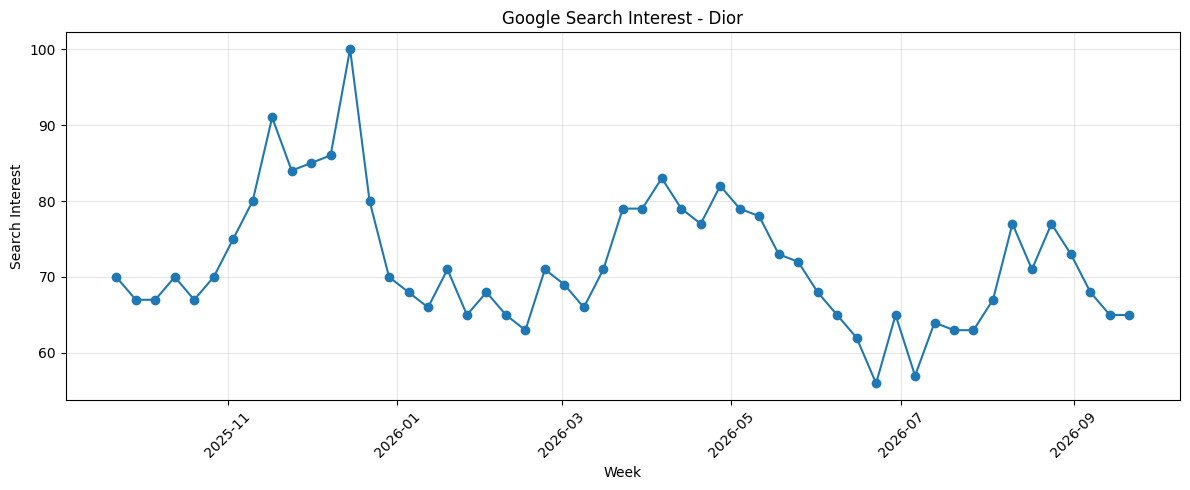

In [54]:
plt.figure(figsize=(12, 5))

plt.plot(
    weekly_trends["week"],
    weekly_trends["search_interest"],
    marker="o"
)

plt.title("Google Search Interest - Dior")
plt.xlabel("Week")
plt.ylabel("Search Interest")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## CỤM 3 — Lấy dữ liệu News từ GDELT

### 3. Thu thập dữ liệu GDELT cải tiến bằng cách chia nhỏ thời gian (Chunking)
Để giải quyết giới hạn 250 bản ghi của GDELT, chúng ta sẽ chia khoảng thời gian 12 tháng qua thành từng phân đoạn nhỏ (12 tháng gần nhất) để gọi API nhiều lần, sau đó gộp lại.

### 3.1 KHỞI TẠO ĐƯỜNG DẪN DRIVE, THIẾT LẬP THAM SỐ VÀ PHÂN CHIA CHU KỲ CHUNKING



In [64]:
import os
from datetime import datetime, timedelta
import pandas as pd
import numpy as np

# Kết nối Google Drive để lưu trữ an toàn
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
except Exception as e:
    print("Cảnh báo: Không thể kết nối Google Drive. Dữ liệu sẽ lưu tạm ở bộ nhớ Colab.")

# Thiết lập đường dẫn thư mục lưu trữ
DATA_DIR = "/content/drive/MyDrive/BTIS/data/"
os.makedirs(DATA_DIR, exist_ok=True)

# Đường dẫn file dữ liệu lưu trữ theo yêu cầu đề tài BTIS
RAW_PATH = os.path.join(DATA_DIR, "gdelt_dior_raw.csv")
CLEAN_PATH = os.path.join(DATA_DIR, "gdelt_dior_clean.csv")
WEEKLY_PATH = os.path.join(DATA_DIR, "gdelt_dior_weekly.csv")
LOG_PATH = os.path.join(DATA_DIR, "request_log.csv")

# --- CẤU HÌNH THỜI GIAN VÀ CHẾ ĐỘ CHẠY ---
TEST_MODE = False  # Chuyển sang False để hệ thống quét đầy đủ 13 tuần (3 tháng)
num_weeks = 2 if TEST_MODE else 13

url = "https://api.gdeltproject.org/api/v2/doc/doc"
query_keyword = "Dior"
today = datetime.now()
chunks = []

for i in range(num_weeks):
    end_date = today - timedelta(days=i * 7)
    start_date = today - timedelta(days=(i + 1) * 7)
    chunks.append((
        start_date.strftime("%Y%m%d%H%M%S"),
        end_date.strftime("%Y%m%d%H%M%S")
    ))

# Sắp xếp chu kỳ từ quá khứ đến hiện tại
chunks.reverse()

print(f"\n[Khởi tạo hoàn tất]")
print(f"- Chế độ TEST_MODE: {TEST_MODE}")
print(f"- Tổng số chu kỳ cần thu thập: {len(chunks)} tuần")
print(f"- Khoảng thời gian thu thập: {chunks[0][0]} -> {chunks[-1][1]}")
print(f"- Thư mục lưu trữ: {DATA_DIR}")

Mounted at /content/drive

[Khởi tạo hoàn tất]
- Chế độ TEST_MODE: False
- Tổng số chu kỳ cần thu thập: 13 tuần
- Khoảng thời gian thu thập: 20260703094412 -> 20261002094412
- Thư mục lưu trữ: /content/drive/MyDrive/BTIS/data/



### 3.2 THỰC HIỆN RETRIEVAL LOOP VỚI CƠ CHẾ RESUME / CHECKPOINT VÀ BACKOFF CHỐNG 429



In [69]:

import time
import requests
import json
import sys
import os
import pandas as pd

all_articles = []
logs_list = []
completed_intervals = set()

# Tự động khôi phục dữ liệu đã hoàn thành từ Google Drive
if os.path.exists(RAW_PATH) and os.path.exists(LOG_PATH):
    try:
        existing_raw = pd.read_csv(RAW_PATH)
        existing_log = pd.read_csv(LOG_PATH)

        all_articles = existing_raw.to_dict('records')
        logs_list = existing_log.to_dict('records')

        for item in logs_list:
            if item.get('status') == 'Success':
                completed_intervals.add((str(item['start_datetime']), str(item['end_datetime'])))
        print(f"[Checkpoint] Phát hiện dữ liệu cũ trên Drive.")
    except Exception as e:
        print(f"[Checkpoint] Lỗi đọc file cũ ({e}). Khởi tạo lại.")
        all_articles = []
        logs_list = []
        completed_intervals = set()

# Xác định phần còn thiếu (chỉ lọc những tuần chưa thành công)
missing_chunks = [ch for ch in chunks if ch not in completed_intervals]

print(f"\n--- TRẠNG THÁI TIẾN TRÌNH --- ")
print(f"Đã có: {len(completed_intervals)}/{len(chunks)} tuần")
print(f"Còn thiếu: {len(missing_chunks)} tuần")
if len(missing_chunks) > 0:
    print(f"Các tuần sẽ thu thập tiếp theo:")
    for idx, (s, e) in enumerate(missing_chunks):
        print(f"  + Tuần {idx+1}: {s} -> {e}")
else:
    print("  -> Tất cả các tuần đã có sẵn dữ liệu thành công!")

total_requests = 0
successful_requests = len(completed_intervals)
failed_requests = 0
limit_reached_count = sum(1 for item in logs_list if item.get('limit_reached') is True)
rate_limit_errors_encountered = 0

print(f"\nBắt đầu xử lý quét dữ liệu GDELT bổ sung...\n")

# Biến flag để kiểm soát việc dừng toàn bộ chương trình khi gặp lỗi 429 nặng
stop_execution = False

for idx, (start, end) in enumerate(chunks):
    if (start, end) in completed_intervals:
        print(f"Tuần {idx+1}/{len(chunks)}: Đã có trên Drive -> Skip.")
        continue

    if stop_execution:
        break

    params = {
        "query": query_keyword,
        "mode": "artlist",
        "format": "json",
        "maxrecords": 250,
        "startdatetime": start,
        "enddatetime": end
    }

    max_retries = 3
    retrieved_count = 0
    status_info = "Failed"
    success_flag = False

    # Thử gọi API tuần hiện tại (1 request chính + tối đa 3 lần retry khi gặp 429)
    for attempt in range(max_retries + 1):
        total_requests += 1
        try:
            response = requests.get(url, params=params, timeout=20)

            if response.status_code == 200:
                try:
                    data_json = response.json()
                    articles_chunk = data_json.get("articles", [])
                    retrieved_count = len(articles_chunk)

                    all_articles.extend(articles_chunk)
                    status_info = "Success"
                    success_flag = True
                    successful_requests += 1
                    break
                except Exception as e:
                    status_info = f"JSONDecodeError_{type(e).__name__}"
                    failed_requests += 1
                    break

            elif response.status_code == 429:
                status_info = "HTTP_429_RateLimit"
                rate_limit_errors_encountered += 1
                if attempt < max_retries:
                    # Áp dụng cơ chế Backoff dài hơn: 60s -> 120s -> 300s
                    backoff_schedule = [60, 120, 300]
                    wait_time = backoff_schedule[attempt]
                    print(f"  -> Gặp lỗi 429 (Rate Limit). Đang chờ {wait_time}s trước khi thử lại lần {attempt+1}/{max_retries}...")
                    time.sleep(wait_time)
                else:
                    failed_requests += 1
                    print(f"  -> Thất bại hoàn toàn tuần {idx+1} do quá giới hạn API sau {max_retries} lần thử lại.")
                    stop_execution = True  # Đánh dấu dừng ngay lập tức
            else:
                status_info = f"HTTP_{response.status_code}"
                failed_requests += 1
                break

        except requests.exceptions.RequestException as e:
            status_info = f"NetworkError_{type(e).__name__}"
            if attempt < max_retries:
                time.sleep(5)
            else:
                failed_requests += 1
                break

    limit_reached = True if retrieved_count == 250 else False
    if limit_reached:
        limit_reached_count += 1
        print(f"  [!] Cảnh báo: Số lượng bài báo chạm ngưỡng tối đa 250, dữ liệu tuần này có thể đã bị giới hạn.")

    # Ghi nhận log của tuần hiện tại
    logs_list = [item for item in logs_list if not (str(item['start_datetime']) == start and str(item['end_datetime']) == end)]
    logs_list.append({
        "week_index": idx + 1,
        "start_datetime": start,
        "end_datetime": end,
        "retrieved_articles": retrieved_count,
        "status": status_info,
        "limit_reached": limit_reached
    })

    # Ghi checkpoint trực tiếp xuống Google Drive
    pd.DataFrame(all_articles).to_csv(RAW_PATH, index=False)
    pd.DataFrame(logs_list).to_csv(LOG_PATH, index=False)

    if success_flag:
        print(f"Tuần {idx+1}/{len(chunks)}: Success -> Thu thập được {retrieved_count} bài báo.")
        # Khoảng nghỉ ngắn 3-5 giây để giữ nhịp độ an toàn
        time.sleep(4)
    else:
        print(f"Tuần {idx+1}/{len(chunks)}: Thất bại với trạng thái [{status_info}].")
        if stop_execution:
            print("\n[Dừng khẩn cấp] Gặp lỗi 429 liên tục! Tiến trình được tạm ngừng để bảo vệ API. Vui lòng thử lại sau.")
            break

# --- THỐNG KÊ KẾT QUẢ CUỐI ---
print("     BÁO CÁO THU THẬP DỮ LIỆU GDELT (Ô 3.2)")
print(f"- Số tuần Success               : {successful_requests}")
print(f"- Số tuần Failed                : {failed_requests}")
print(f"- Số lỗi HTTP 429 gặp phải      : {rate_limit_errors_encountered}")
print(f"- Tổng số bài thô hiện có       : {len(all_articles)}")
if len(all_articles) > 0 and 'seendate' in pd.DataFrame(all_articles).columns:
    dates = pd.to_datetime(pd.DataFrame(all_articles)['seendate'], errors='coerce')
    print(f"- Khoảng thời gian thực tế thu thập: {dates.min()} -> {dates.max()}")


[Checkpoint] Phát hiện dữ liệu cũ trên Drive.

--- TRẠNG THÁI TIẾN TRÌNH --- 
Đã có: 9/13 tuần
Còn thiếu: 6 tuần
Các tuần sẽ thu thập tiếp theo:
  + Tuần 1: 20260821094412 -> 20260828094412
  + Tuần 2: 20260828094412 -> 20260904094412
  + Tuần 3: 20260904094412 -> 20260911094412
  + Tuần 4: 20260911094412 -> 20260918094412
  + Tuần 5: 20260918094412 -> 20260925094412
  + Tuần 6: 20260925094412 -> 20261002094412

Bắt đầu xử lý quét dữ liệu GDELT bổ sung...

Tuần 1/13: Đã có trên Drive -> Skip.
Tuần 2/13: Đã có trên Drive -> Skip.
Tuần 3/13: Đã có trên Drive -> Skip.
Tuần 4/13: Đã có trên Drive -> Skip.
Tuần 5/13: Đã có trên Drive -> Skip.
Tuần 6/13: Đã có trên Drive -> Skip.
Tuần 7/13: Đã có trên Drive -> Skip.
Tuần 8/13: Success -> Thu thập được 152 bài báo.
  -> Gặp lỗi 429 (Rate Limit). Đang chờ 60s trước khi thử lại lần 1/3...
  [!] Cảnh báo: Số lượng bài báo chạm ngưỡng tối đa 250, dữ liệu tuần này có thể đã bị giới hạn.
Tuần 9/13: Success -> Thu thập được 250 bài báo.
  -> Gặp lỗi

KeyboardInterrupt: 

### 3.3 LÀM SẠCH DỮ LIỆU VÀ KẾT XUẤT BÁO CÁO THẨM ĐỊNH BTIS

In [ ]:
# =====================================================================
# Ô 3.3: LÀM SẠCH DỮ LIỆU CHUẨN HÓA TUẦN (W-SUN) VÀ LƯU TRỮ TRỰC TIẾP
# =====================================================================
request_log = pd.DataFrame(logs_list)
df_raw_news = pd.DataFrame(all_articles)

missing_date_count = 0
missing_url_count = 0
duplicate_url_count = 0
total_raw_articles = len(df_raw_news)
total_cleaned_articles = 0

if not df_raw_news.empty:
    # Đếm số lượng thiếu URL
    if "url" in df_raw_news.columns:
        missing_url_count = df_raw_news["url"].isna().sum() + (df_raw_news["url"].astype(str).str.strip() == "").sum()
    else:
        missing_url_count = len(df_raw_news)

    # Giữ đúng các trường dữ liệu theo quy định
    news_processed = df_raw_news[["title", "seendate", "domain", "url"]].copy()
    news_processed.columns = ["title", "published_date", "source", "url"]

    # Loại bỏ URL rỗng
    news_processed = news_processed.dropna(subset=["url"])
    news_processed = news_processed[news_processed["url"].astype(str).str.strip() != ""]

    # Chuyển đổi định dạng ngày tháng và loại bỏ dòng thiếu ngày
    news_processed["published_date"] = pd.to_datetime(news_processed["published_date"], errors="coerce")
    missing_date_count = news_processed["published_date"].isna().sum()
    news_processed = news_processed.dropna(subset=["published_date"])

    # Lọc bỏ trùng lặp URL
    before_dedup = len(news_processed)
    news_processed = news_processed.drop_duplicates(subset=["url"])
    duplicate_url_count = before_dedup - len(news_processed)

    total_cleaned_articles = len(news_processed)

    # Quy đổi ngày đăng về ngày bắt đầu tuần (Thứ Hai) để đảm bảo đồng bộ hoàn hảo với Google Trends
    news_processed["week"] = news_processed["published_date"].dt.to_period("W-SUN").dt.start_time

    # Tổng hợp tần suất tin bài thực tế theo tuần
    weekly_media = (
        news_processed
        .groupby("week")
        .size()
        .reset_index(name="media_count")
    )
    total_weeks_with_data = len(weekly_media)
else:
    news_processed = pd.DataFrame(columns=["title", "published_date", "source", "url", "week"])
    weekly_media = pd.DataFrame(columns=["week", "media_count"])
    total_weeks_with_data = 0

# Ghi đè lưu trữ dữ liệu sạch và dữ liệu theo tuần xuống Google Drive
news_processed.to_csv(CLEAN_PATH, index=False)
weekly_media.to_csv(WEEKLY_PATH, index=False)

# --- IN BÁO CÁO THẨM ĐỊNH CHẤT LƯỢNG ---
print("====================================================")
print("     BÁO CÁO THẨM ĐỊNH CHẤT LƯỢNG GDELT")
print("====================================================")
print(f"1. Tổng số requests đã thực hiện       : {total_requests}")
print(f"2. Số requests thành công (HTTP 200)   : {successful_requests}")
print(f"3. Số requests thất bại/bị lỗi        : {failed_requests}")
print(f"4. Tổng số bài báo thô thu thập được    : {total_raw_articles}")
print(f"5. Tổng số bài báo sạch sau xử lý      : {total_cleaned_articles}")
print(f"6. Số bài bị loại do thiếu ngày        : {missing_date_count}")
print(f"7. Số bài bị loại do thiếu URL         : {missing_url_count}")
print(f"8. Số bài trùng lặp bị lọc bỏ (Dup URL): {duplicate_url_count}")
print(f"9. Số khoảng thời gian chạm ngưỡng 250 : {limit_reached_count}")
print(f"10. Số tuần thực tế có dữ liệu         : {total_weeks_with_data}")
print("====================================================")

if total_weeks_with_data > 0:
    print(f"\nMin GDELT Week : {weekly_media['week'].min().strftime('%Y-%m-%d')}")
    print(f"Max GDELT Week : {weekly_media['week'].max().strftime('%Y-%m-%d')}")
    print(f"Số lượng tuần của GDELT: {total_weeks_with_data}")

# Hiển thị các mẫu dữ liệu
print("\n--- 5 DÒNG ĐẦU BẢNG NHẬT KÝ (request_log) ---")
display(request_log.head())

print("\n--- 5 DÒNG ĐẦU BẢNG BÀI BÁO ĐÃ SẠCH (news_processed) ---")
display(news_processed.head())

print("\n--- BẢNG TẦN SUẤT TRUYỀN THÔNG (weekly_media) ---")
display(weekly_media.head(13))

### CỤM 4 — Merge + Feature Engineering


### CỤM 4.1 - CHUẨN HÓA DỮ LIỆU HAI BẢNG


In [ ]:
trends = weekly_trends.copy()
media = weekly_media.copy()

trends["week"] = pd.to_datetime(
    trends["week"],
    errors="coerce"
)

media["week"] = pd.to_datetime(
    media["week"],
    errors="coerce"
)

# Loại bỏ dòng không có week
trends = trends.dropna(subset=["week"])
media = media.dropna(subset=["week"])

# Chuẩn hóa về tuần bắt đầu từ thứ Hai
trends["week"] = (
    trends["week"]
    .dt.to_period("W-SUN")
    .dt.start_time
)

media["week"] = (
    media["week"]
    .dt.to_period("W-SUN")
    .dt.start_time
)

# Đảm bảo mỗi tuần chỉ có một dòng
trends = (
    trends
    .groupby("week", as_index=False)["search_interest"]
    .mean()
)

media = (
    media
    .groupby("week", as_index=False)["media_count"]
    .sum()
)

print("Google Trends:")
display(trends.head())

print("\nGDELT:")
display(media.head())

### 4.2. MERGE Google Trends + GDELT

In [ ]:
df = pd.merge(
    trends,
    media,
    on="week",
    how="outer",
    indicator=True
)

# Sắp xếp theo thời gian
df = (
    df
    .sort_values("week")
    .reset_index(drop=True)
)

print("Kết quả MERGE:")
display(df)

print(df["_merge"].value_counts())

In [ ]:
print("===== GOOGLE TRENDS =====")
print("Min:", trends["week"].min())
print("Max:", trends["week"].max())
print("Số tuần:", len(trends))

print("\n===== GDELT =====")
print("Min:", media["week"].min())
print("Max:", media["week"].max())
print("Số tuần:", len(media))